# 02 — Emotion Detection
**Project:** Semantic Book Recommender — IT4142 HUST  
**Model:** `j-hartmann/emotion-english-distilroberta-base`  
**Input:** `data/processed/books_clean.csv`  
**Output:**
- `data/processed/books_with_emotions.csv` — clean dataset + emotion columns
- ChromaDB metadata updated với `top_emotions` (nếu ChromaDB đã được khởi tạo)
- `reports/figures/plot6_emotion_distribution.png`

Pipeline:
1. Load data + model
2. Run inference trên toàn corpus (batch)
3. Extract `top_emotions` (top-2 labels per book)
4. Save enriched CSV
5. Upsert `top_emotions` vào ChromaDB (nếu tồn tại)
6. Plot emotion distribution (Plot 6 của PRD)


## 0. Setup

In [6]:
# pip install transformers torch chromadb
import pandas as pd
import numpy as np
import json, time
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from transformers import pipeline
import chromadb
from chromadb.config import Settings

DATA_PATH    = Path('data/processed/books_clean.csv')
OUT_PATH     = Path('data/processed/books_with_emotions.csv')
CHROMA_PATH  = Path('data/chroma_db')
FIGURE_PATH  = Path('reports/figures')
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 150,
    'figure.facecolor': 'white', 'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False, 'axes.spines.right': False,
})

print('Setup OK')

Setup OK


## 1. Load Data

In [7]:
df = pd.read_csv(DATA_PATH)
print(f'Books loaded: {len(df):,}')
df[['isbn13', 'title', 'description']].head(3)

Books loaded: 11,606


,isbn13,title,description
0,9780002188319,The Complete Book of the World Cup,This is the ultimate reference book on the Wor...
1,9780002240802,The Last Thing He Wanted,"Journalist Elena McMahon watches her evasive, ..."
2,9780002246484,Royal Assassin,Barely escaping with his life after his first ...


## 2. Load Emotion Model

> Model size: ~330MB (DistilRoBERTa-base).  
> Download tự động từ HuggingFace Hub lần đầu chạy.

In [8]:
MODEL_NAME = 'j-hartmann/emotion-english-distilroberta-base'

print(f'Loading model: {MODEL_NAME}')
t0 = time.time()

emotion_pipe = pipeline(
    'text-classification',
    model=MODEL_NAME,
    top_k=None,          # return scores for ALL labels
    device=-1,           # CPU (-1); set to 0 for CUDA GPU
    truncation=True,
    max_length=512,      # DistilRoBERTa max context
)

print(f'Loaded in {time.time()-t0:.1f}s')

# Smoke test
sample = emotion_pipe('A heartbreaking tale of loss and longing.')
print('Smoke test output:')
for item in sorted(sample[0], key=lambda x: x['score'], reverse=True):
    print(f"  {item['label']:10s}: {item['score']:.4f}")

Loading model: j-hartmann/emotion-english-distilroberta-base


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loaded in 1.3s
Smoke test output:
  sadness   : 0.9591
  fear      : 0.0173
  neutral   : 0.0106
  surprise  : 0.0050
  disgust   : 0.0045
  joy       : 0.0025
  anger     : 0.0010


## 3. Batch Inference

**Strategy:** Run on first 512 tokens (model max).  
Truncation handled by the pipeline automatically via `max_length=512`.

In [16]:
BATCH_SIZE = 32  # reduce to 16 if OOM
CHECKPOINT_PATH = Path('data/processed/emotions_checkpoint.csv')

# Resume from checkpoint if exists
if CHECKPOINT_PATH.exists():
    df_done = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(df_done['isbn13'].astype(str))
    print(f'Checkpoint found: {len(done_ids):,} already processed')
else:
    df_done = pd.DataFrame()
    done_ids = set()
    print('No checkpoint — starting fresh')

df_todo = df[~df['isbn13'].astype(str).isin(done_ids)].reset_index(drop=True)
print(f'Remaining: {len(df_todo):,} books')

Checkpoint found: 11,552 already processed
Remaining: 54 books


In [17]:
EMOTION_LABELS = ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral']

def parse_emotion_output(pipe_output: list) -> dict:
    """
    Convert pipeline output list of {label, score} dicts
    into a flat dict: {emotion: score, ..., top_emotions: 'joy,sadness'}
    """
    scores = {item['label'].lower(): round(item['score'], 4) for item in pipe_output}
    # Ensure all labels present even if model skips one
    for label in EMOTION_LABELS:
        scores.setdefault(label, 0.0)
    # top-2 emotions
    top2 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:2]
    scores['top_emotions'] = ','.join([e for e, _ in top2])
    return scores


# Run inference in batches with tqdm progress bar
new_rows = []
descriptions = df_todo['description'].tolist()
isbns        = df_todo['isbn13'].astype(str).tolist()

t0 = time.time()
for start in tqdm(range(0, len(df_todo), BATCH_SIZE), desc='Emotion inference'):
    batch_texts = descriptions[start : start + BATCH_SIZE]
    batch_ids   = isbns[start : start + BATCH_SIZE]

    batch_out = emotion_pipe(batch_texts)

    for isbn, out in zip(batch_ids, batch_out):
        parsed = parse_emotion_output(out)
        parsed['isbn13'] = isbn
        new_rows.append(parsed)

    # Save checkpoint every 500 books
    if (start // BATCH_SIZE) % (500 // BATCH_SIZE) == 0 and new_rows:
        df_checkpoint = pd.concat([
            df_done,
            pd.DataFrame(new_rows)
        ], ignore_index=True)
        df_checkpoint.to_csv(CHECKPOINT_PATH, index=False)

elapsed = time.time() - t0
print(f'\nInference done in {elapsed/60:.1f} min  ({elapsed/len(df_todo)*1000:.0f} ms/book)')

Emotion inference:   0%|          | 0/2 [00:00<?, ?it/s]


Inference done in 0.0 min  (38 ms/book)


## 4. Merge Emotion Scores into Main DataFrame

In [18]:
# Combine checkpoint + new rows
all_emotion_rows = pd.concat([
    df_done,
    pd.DataFrame(new_rows)
], ignore_index=True)

# Emotion columns to merge
emotion_cols = EMOTION_LABELS + ['top_emotions']
df_emotions = all_emotion_rows[['isbn13'] + emotion_cols].copy()
df_emotions['isbn13'] = df_emotions['isbn13'].astype(str)

# Merge onto main df
df['isbn13'] = df['isbn13'].astype(str)
df_final = df.merge(df_emotions, on='isbn13', how='left')

# Fill any books that still have no emotion (shouldn't happen)
df_final['top_emotions'] = df_final['top_emotions'].fillna('neutral')
for label in EMOTION_LABELS:
    df_final[label] = df_final[label].fillna(0.0)

print(f'Merged shape: {df_final.shape}')
print(f'Sample top_emotions distribution:')
print(df_final['top_emotions'].value_counts().head(10))

Merged shape: (11606, 21)
Sample top_emotions distribution:
top_emotions
neutral,joy         2802
neutral,surprise    1235
fear,neutral        1160
neutral,disgust     1095
joy,neutral          893
neutral,fear         673
neutral,anger        302
sadness,neutral      297
fear,anger           289
neutral,sadness      253
Name: count, dtype: int64


## 5. Save Enriched Dataset

In [19]:
df_final.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Columns: {df_final.columns.tolist()}')

Saved → data/processed/books_with_emotions.csv
Columns: ['isbn13', 'title', 'authors', 'description', 'categories', 'tag_clean', 'thumbnail', 'average_rating', 'ratings_count', 'published_year', 'num_pages', 'description_length', 'book_age', 'joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral', 'top_emotions']


## 7. Plot 6 — Emotion Distribution Across Corpus

In [20]:
from collections import Counter


EMOTION_COLORS = {
    'joy'     : '#FFD166',
    'sadness' : '#6A9AB0',
    'fear'    : '#8C5E8B',
    'anger'   : '#EF4444',
    'surprise': '#F97316',
    'disgust' : '#84CC16',
    'neutral' : '#94A3B8',
}

# Count each emotion appearing in top_emotions (top-2 per book)
emotion_counter = Counter()
for row in df_final['top_emotions'].dropna():
    for e in str(row).split(','):
        e = e.strip()
        if e:
            emotion_counter[e] += 1

emotion_df = (
    pd.DataFrame(emotion_counter.items(), columns=['emotion', 'count'])
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print('Emotion counts (top-2 per book):')
print(emotion_df.to_string(index=False))

Emotion counts (top-2 per book):
 emotion  count
 neutral   9227
     joy   4065
    fear   3405
 disgust   2127
surprise   1809
   anger   1295
 sadness   1284


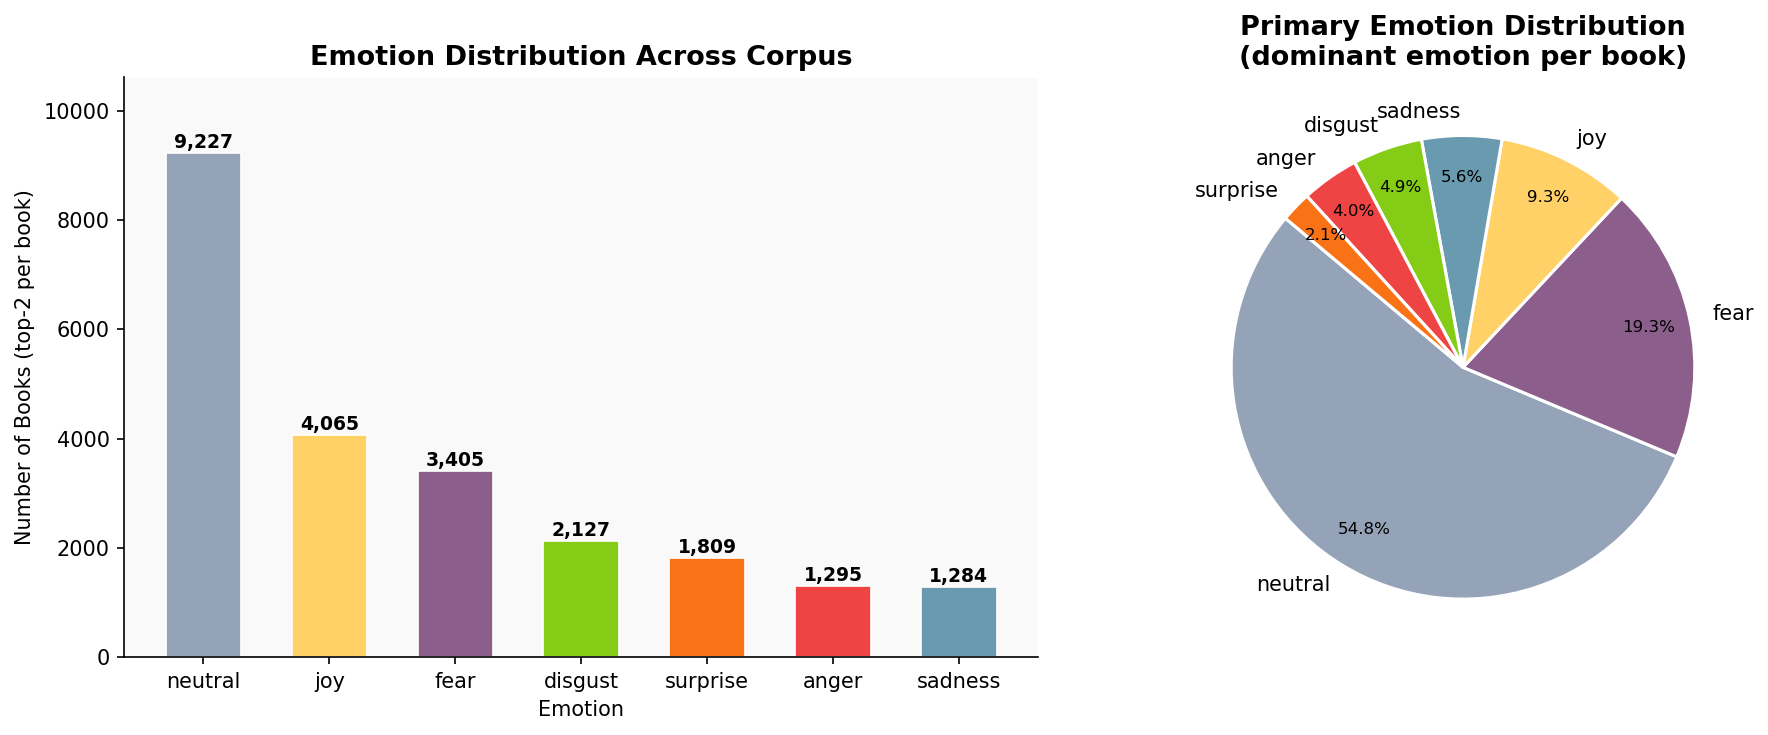

Saved: reports/figures/plot6_emotion_distribution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Bar chart ---
ax = axes[0]
bar_colors = [EMOTION_COLORS.get(e, '#888') for e in emotion_df['emotion']]
bars = ax.bar(emotion_df['emotion'], emotion_df['count'], color=bar_colors,
              edgecolor='white', linewidth=0.8, width=0.6)

# Value labels on top of bars
for bar, val in zip(bars, emotion_df['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
        f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_title('Emotion Distribution Across Corpus', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Number of Books (top-2 per book)')
ax.set_ylim(0, emotion_df['count'].max() * 1.15)

# --- Pie chart (primary emotion only) ---
ax2 = axes[1]

# Primary emotion = first of top_emotions
primary_counts = (
    df_final['top_emotions']
    .dropna()
    .str.split(',').str[0]
    .str.strip()
    .value_counts()
)

pie_colors = [EMOTION_COLORS.get(e, '#888') for e in primary_counts.index]
wedges, texts, autotexts = ax2.pie(
    primary_counts.values,
    labels=primary_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.82,
)
for at in autotexts:
    at.set_fontsize(8)

ax2.set_title('Primary Emotion Distribution\n(dominant emotion per book)',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot6_emotion_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: reports/figures/plot6_emotion_distribution.png')

## 8. Per-Category Emotion Heatmap (Bonus insight)

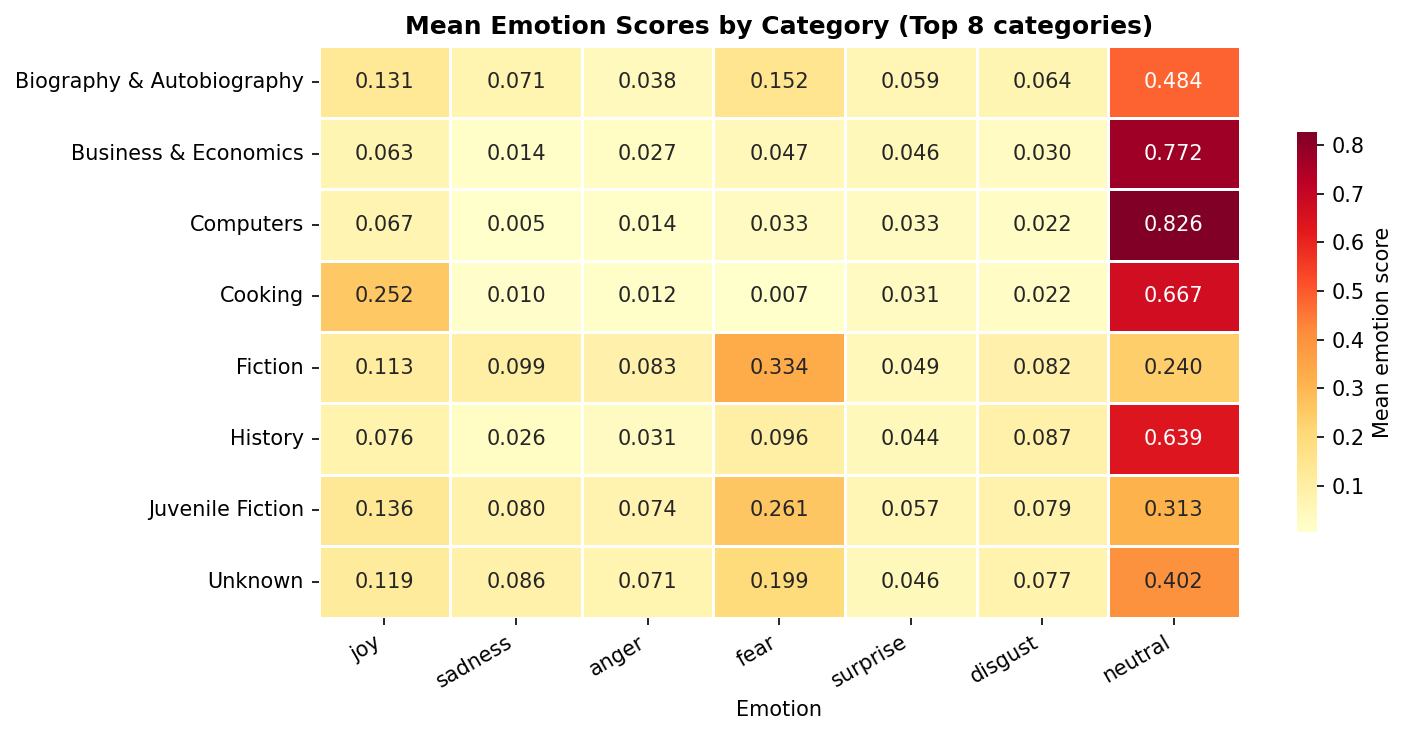

Saved: reports/figures/plot6b_emotion_by_category.png


In [22]:
TOP_CATS = df_final['categories'].value_counts().head(8).index.tolist()

heatmap_data = (
    df_final[df_final['categories'].isin(TOP_CATS)]
    .groupby('categories')[EMOTION_LABELS]
    .mean()
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    ax=ax,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Mean emotion score'},
)
ax.set_title('Mean Emotion Scores by Category (Top 8 categories)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Emotion')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'plot6b_emotion_by_category.png', bbox_inches='tight')
plt.show()
print('Saved: reports/figures/plot6b_emotion_by_category.png')

## 10. Cleanup Checkpoint

In [24]:
import os
if CHECKPOINT_PATH.exists():
    os.remove(CHECKPOINT_PATH)
    print('Checkpoint deleted (inference complete)')
else:
    print('No checkpoint to delete')

Checkpoint deleted (inference complete)


---
## Done ✓

**Artifacts produced:**
- `data/processed/books_with_emotions.csv` — full dataset + 7 emotion score cols + `top_emotions`
- `reports/figures/plot6_emotion_distribution.png` — bar + pie chart
- `reports/figures/plot6b_emotion_by_category.png` — heatmap by category

**Next step:** `07_evaluation_comparison.ipynb` — final Precision@K table + visualization.